In [ ]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Importing the train and test set
train = pd.read_csv('/content/mnist_train.csv')
test = pd.read_csv('/content/mnist_test.csv')

In [ ]:
# Creating a seperate variables containing the labels and the numeric data respectively
y_train = train.iloc[:, 0]
X_train = train.iloc[:, 1:]
y_test = test.iloc[:, 0]
X_test = test.iloc[:, 1:]

In [ ]:
# Looking at the Acutal data
X_train.head()

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


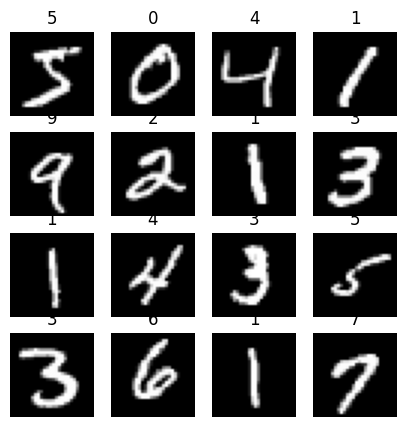

In [ ]:
# Visualizing the data
plt.figure(figsize=(5, 5))
for i in range(16):
  plt.subplot(4, 4, i+1)
  plt.imshow(X_train.iloc[i].values.reshape(28, 28), cmap='gray')
  plt.title(y_train.iloc[i])
  plt.axis('off')

In [ ]:
# Feature Scaling
X_train = X_train/255
X_test = X_test/255

In [ ]:
# Building the model - Artificial Neural Network (ANN)
import tensorflow as tf
model = tf.keras.models.Sequential(layers=[
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dense(units=10, activation='softmax')])

In [ ]:
# Compiling the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9386 - loss: 0.2018 - val_accuracy: 0.9593 - val_loss: 0.1261
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9740 - loss: 0.0846 - val_accuracy: 0.9728 - val_loss: 0.0881
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9816 - loss: 0.0571 - val_accuracy: 0.9783 - val_loss: 0.0747
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9864 - loss: 0.0433 - val_accuracy: 0.9789 - val_loss: 0.0730
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9887 - loss: 0.0348 - val_accuracy: 0.9790 - val_loss: 0.0732
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9911 - loss: 0.0272 - val_accuracy: 0.9803 - val_loss: 0.0766
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9927 - loss: 0.0228 - val_accuracy: 0.9786 - val_loss: 0.0795
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9930 - loss: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
original = 4 
prediction = 4


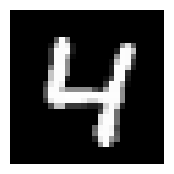

In [ ]:
# Predicting a single random number
value = 56
y_pred = model.predict(X_test.iloc[value].values.reshape(1, 784)).argmax()
print('original =', y_test.iloc[value], '\nprediction =', y_pred)
plt.figure(figsize=(2, 2))
plt.axis('off')
plt.imshow(X_test.iloc[value].values.reshape(28, 28), cmap='gray')

In [ ]:
# Buiding the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


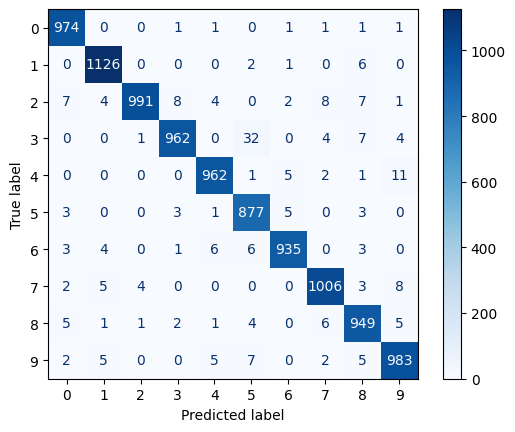

In [ ]:
# Displaying the Confusion matrix
disp.plot(cmap='Blues')
plt.show()